In [1]:
# =====================================
# IoT Sensor Anomaly Detection
# Machine Learning Internship Project 2
# Developed by Himanshi Arora
# =====================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [2]:
# Load Dataset

df = pd.read_csv("../data/industrial_iot_fault_detection.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# Display First Five Rows

df.head()

,Timestamp,Vibration (mm/s),Temperature (°C),Pressure (bar),RMS Vibration,Mean Temp,Fault Label
0,2023-03-10 00:00:00,0.437086,64.810634,7.785117,0.601657,90.561384,1
1,2023-03-10 00:01:00,0.955643,93.352076,7.740936,0.601657,90.561384,1
2,2023-03-10 00:02:00,0.758795,119.835667,9.718764,0.601657,90.561384,0
3,2023-03-10 00:03:00,0.638793,108.577991,7.748639,0.601657,90.561384,1
4,2023-03-10 00:04:00,0.240417,114.524892,7.815849,0.601657,90.561384,0


In [4]:
# Dataset Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 7


In [5]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         1000 non-null   str    
 1   Vibration (mm/s)  1000 non-null   float64
 2   Temperature (°C)  1000 non-null   float64
 3   Pressure (bar)    1000 non-null   float64
 4   RMS Vibration     1000 non-null   float64
 5   Mean Temp         1000 non-null   float64
 6   Fault Label       1000 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 73.4 KB


In [6]:
# Statistical Summary

df.describe()

,Vibration (mm/s),Temperature (°C),Pressure (bar),RMS Vibration,Mean Temp,Fault Label
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,0.541231,90.561384,8.507217,0.601657,9.056138e+01,0.479000
std,0.262924,23.375191,0.872023,0.000000,1.421797e-14,0.652675
min,0.104169,50.257461,7.000035,0.601657,9.056138e+01,0.000000
25%,0.312376,69.285942,7.784053,0.601657,9.056138e+01,0.000000
50%,0.547127,91.498713,8.501842,0.601657,9.056138e+01,0.000000
75%,0.769888,110.837205,9.277311,0.601657,9.056138e+01,1.000000
max,0.999746,129.953098,9.993463,0.601657,9.056138e+01,2.000000


In [7]:
# Missing Values

print(df.isnull().sum())

Timestamp           0
Vibration (mm/s)    0
Temperature (°C)    0
Pressure (bar)      0
RMS Vibration       0
Mean Temp           0
Fault Label         0
dtype: int64


In [8]:
# Duplicate Rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


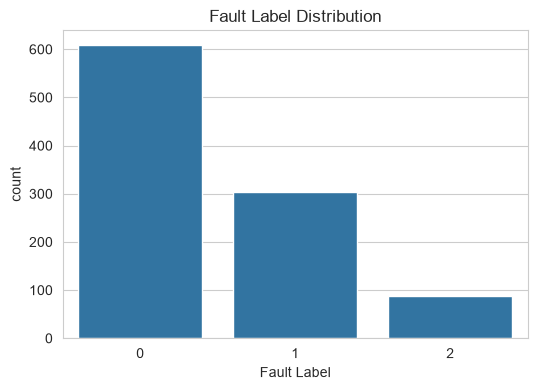

In [9]:
# Fault Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Fault Label"
)

plt.title("Fault Label Distribution")
plt.show()

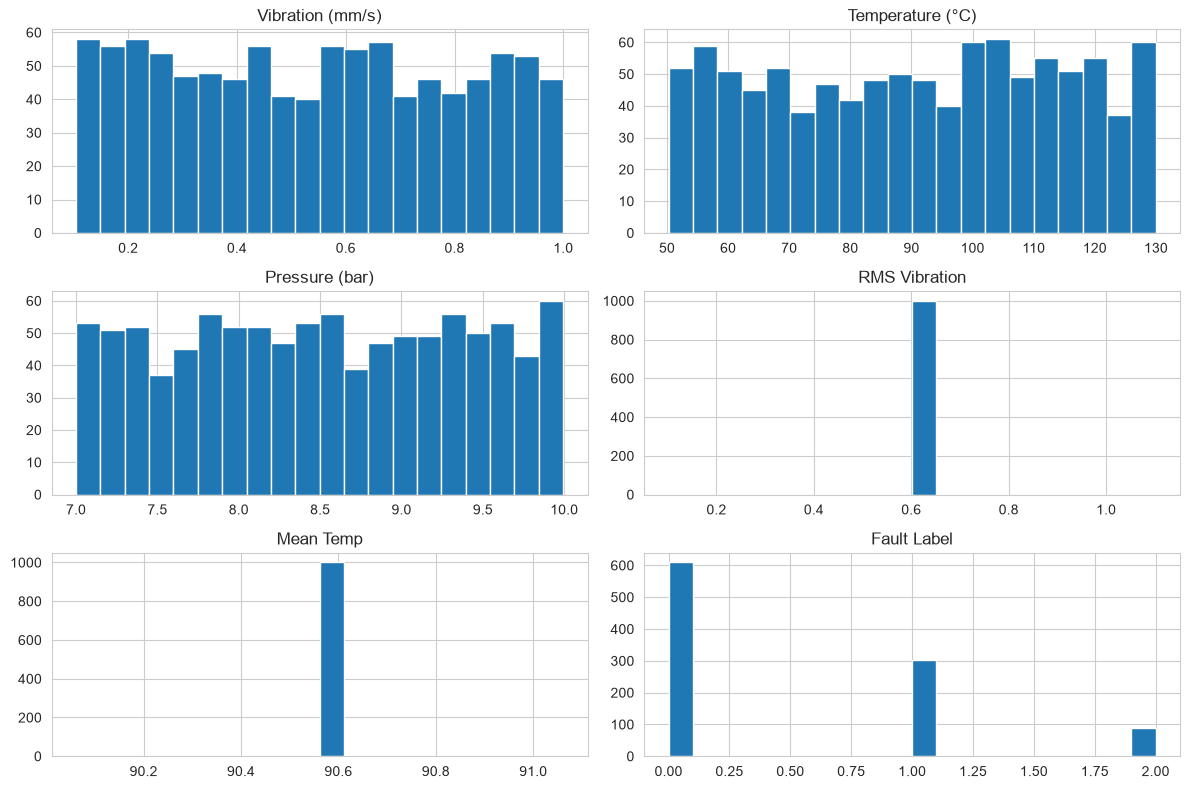

In [10]:
# Histograms

df.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

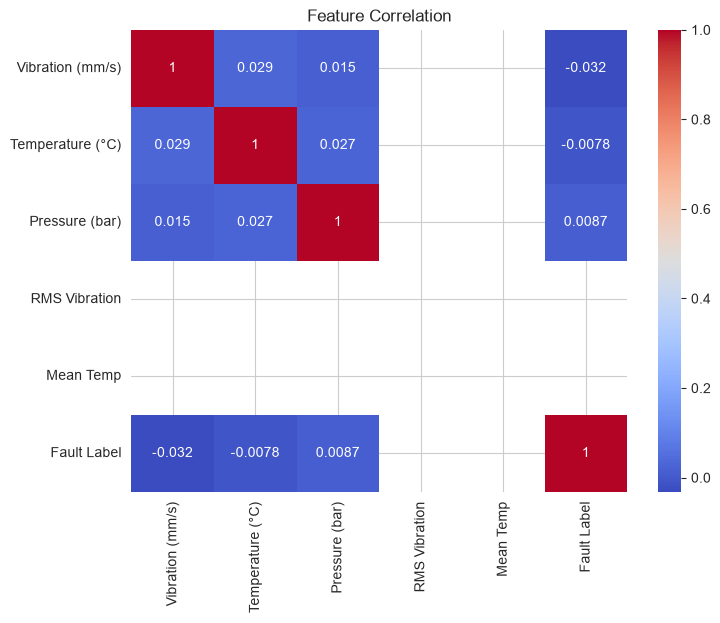

In [11]:
# Correlation Matrix

plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

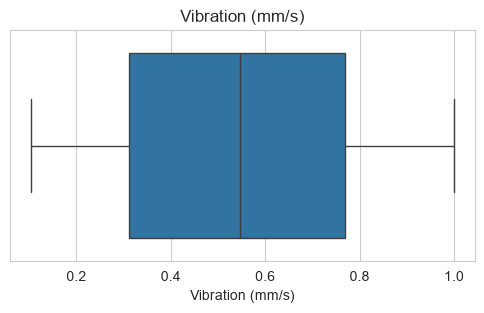

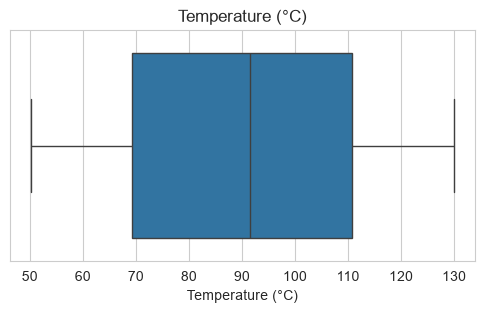

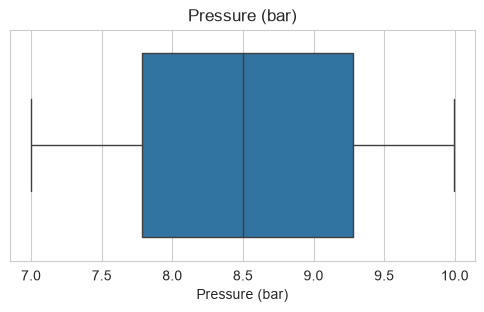

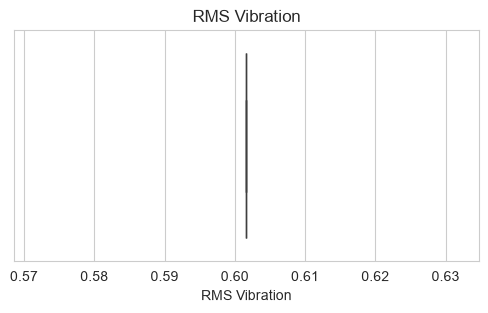

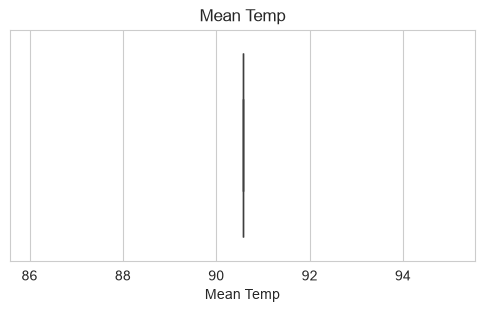

In [12]:
# Boxplots

numeric_columns = [
    "Vibration (mm/s)",
    "Temperature (°C)",
    "Pressure (bar)",
    "RMS Vibration",
    "Mean Temp"
]

for column in numeric_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

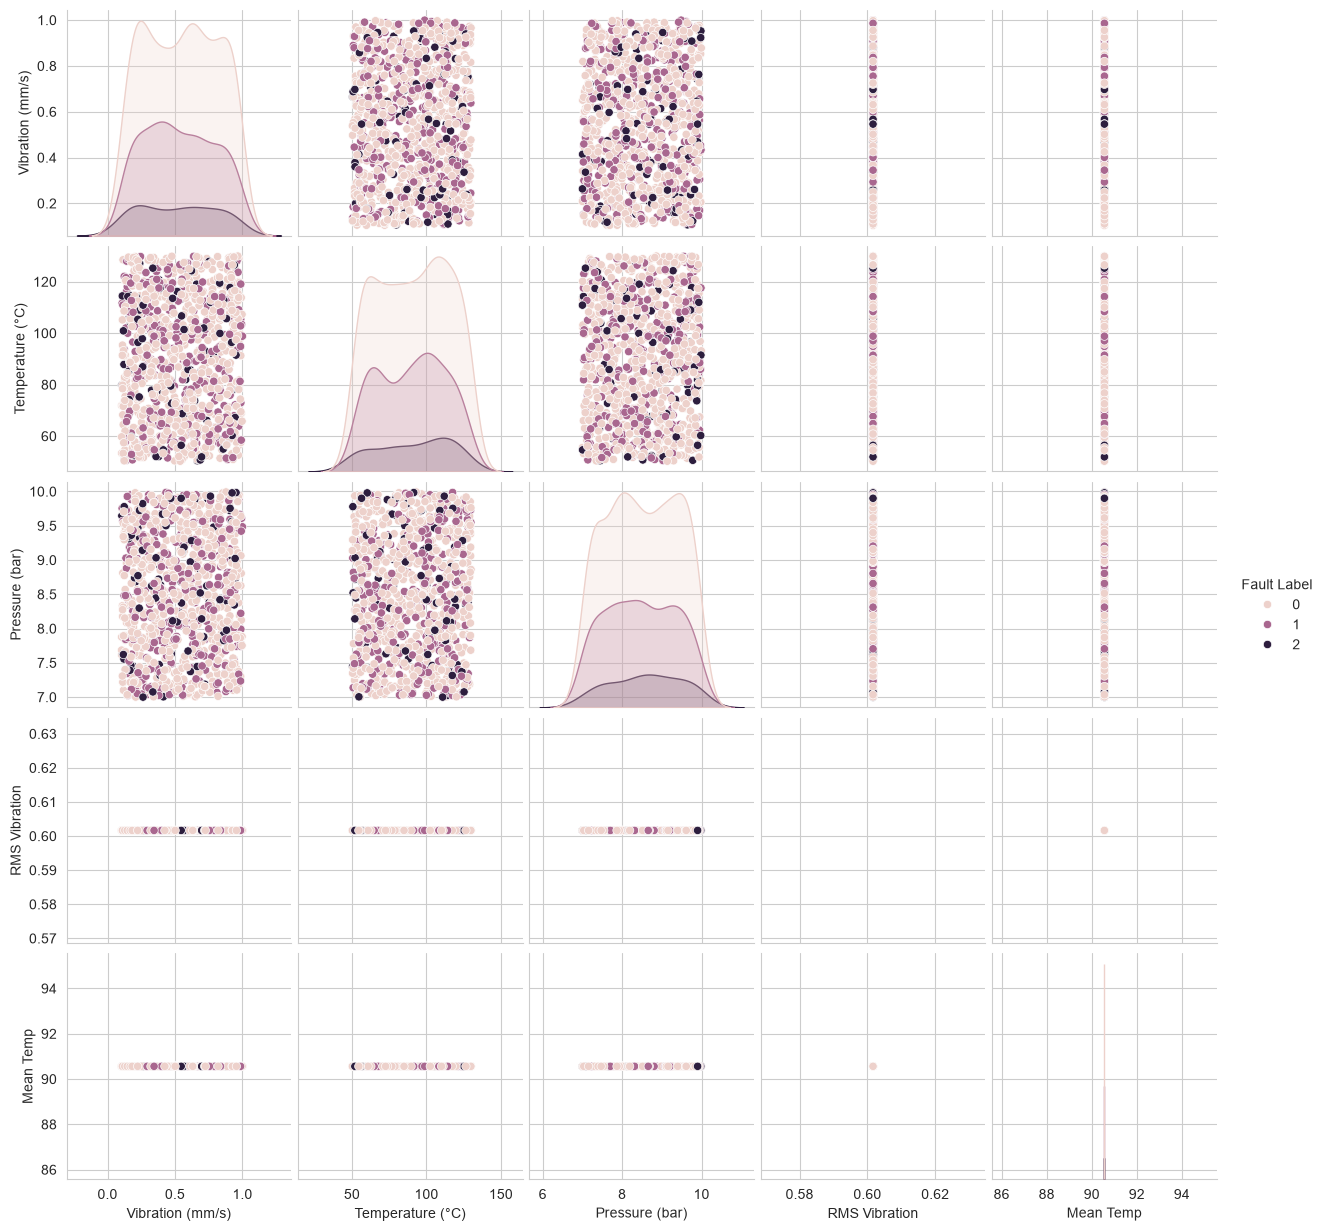

In [13]:
# Pairplot

sns.pairplot(
    df,
    hue="Fault Label"
)

plt.show()

In [14]:
# =====================================
# Feature Selection
# =====================================

X = df.drop(columns=["Timestamp", "Fault Label"])
y = df["Fault Label"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (1000, 5)
Target Shape : (1000,)


In [15]:
# =====================================
# Train Test Split
# =====================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])


Training Samples : 800
Testing Samples : 200


In [16]:
# =====================================
# Import Models
# =====================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

models = {

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42),

    "Logistic Regression":
    LogisticRegression(max_iter=1000)

}

In [17]:
# =====================================
# Model Comparison
# =====================================

from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    results[name] = accuracy

    print(f"{name} Accuracy : {accuracy:.4f}")

Decision Tree Accuracy : 0.4550
Random Forest Accuracy : 0.5650
Gradient Boosting Accuracy : 0.5550
Logistic Regression Accuracy : 0.6100


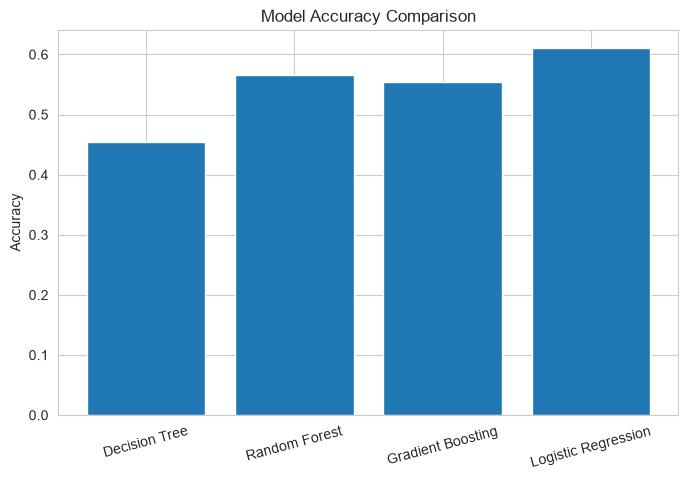

In [18]:
# =====================================
# Accuracy Comparison
# =====================================

plt.figure(figsize=(8,5))

plt.bar(
    results.keys(),
    results.values()
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

In [19]:
# =====================================
# Best Model
# =====================================

best_model_name = max(results, key=results.get)

print("Best Model :", best_model_name)

best_model = models[best_model_name]

Best Model : Logistic Regression


In [20]:
# =====================================
# Predictions
# =====================================

y_pred = best_model.predict(X_test)

In [21]:
# =====================================
# Final Accuracy
# =====================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Final Accuracy : {accuracy*100:.2f}%")

Final Accuracy : 61.00%


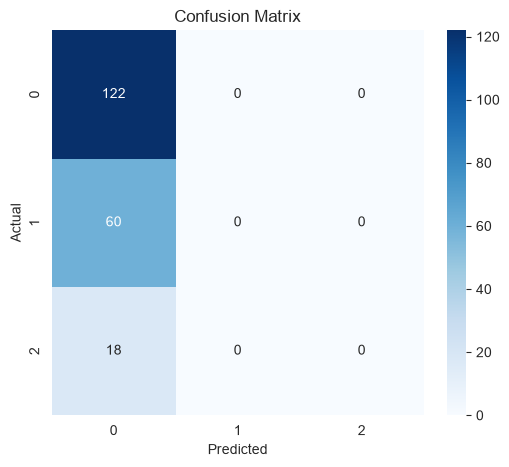

In [22]:
# =====================================
# Confusion Matrix
# =====================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [23]:
# =====================================
# Classification Report
# =====================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       122
           1       0.00      0.00      0.00        60
           2       0.00      0.00      0.00        18

    accuracy                           0.61       200
   macro avg       0.20      0.33      0.25       200
weighted avg       0.37      0.61      0.46       200



In [24]:
# =====================================
# Feature Importance
# =====================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title("Feature Importance")

    plt.show()

else:

    print("Feature importance not available for this model.")

Feature importance not available for this model.


In [25]:
# =====================================
# Save Model
# =====================================

import joblib
from pathlib import Path

model_path = Path("../models/iot_anomaly_model.pkl")

joblib.dump(best_model, model_path)

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [26]:
# =====================================
# Hyperparameter Tuning
# =====================================

from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_estimators": [100, 200, 300],

    "max_depth": [5, 10, 15, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]

}

grid_search = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(X_train, y_train)

print("Best Parameters:")

print(grid_search.best_params_)

print()

print("Best Accuracy:")

print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}

Best Accuracy:
0.6074999999999999


In [27]:
# =====================================
# Optimized Model
# =====================================

best_rf = grid_search.best_estimator_

prediction = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, prediction)

print(f"Optimized Accuracy : {accuracy*100:.2f}%")

Optimized Accuracy : 61.00%


In [29]:
print(df["Fault Label"].unique())
print(df["Fault Label"].value_counts())
print(y.unique())
print(type(y.iloc[0]))

[1 0 2]
Fault Label
0    609
1    303
2     88
Name: count, dtype: int64
[1 0 2]
<class 'numpy.int64'>


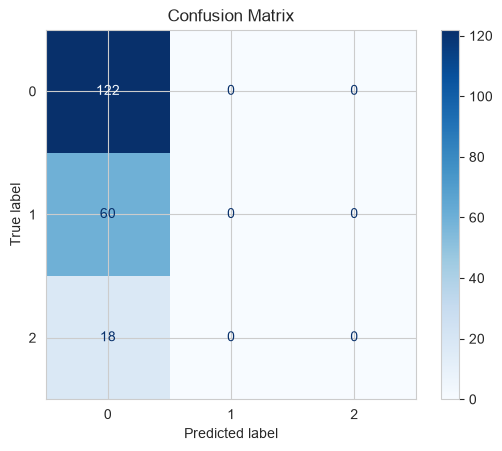

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.61      1.00      0.76       122
           1       0.00      0.00      0.00        60
           2       0.00      0.00      0.00        18

    accuracy                           0.61       200
   macro avg       0.20      0.33      0.25       200
weighted avg       0.37      0.61      0.46       200



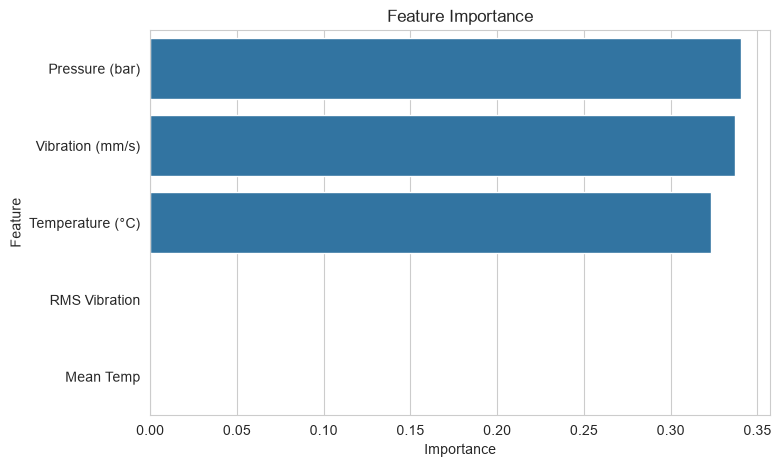

In [32]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [33]:
import joblib

joblib.dump(
    best_rf,
    "../models/iot_anomaly_model.pkl"
)

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [34]:
results_df = pd.DataFrame({

    "Model": list(results.keys()),

    "Accuracy": list(results.values())

})

results_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("✅ Comparison Saved")

✅ Comparison Saved


In [35]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_prediction = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_prediction)

print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Accuracy: 0.5250


In [36]:
from sklearn.svm import SVC

svm = SVC(probability=True, random_state=42)

svm.fit(X_train, y_train)

svm_prediction = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_prediction)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.6100


In [38]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Logistic Regression",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        results["Decision Tree"],
        results["Random Forest"],
        results["Gradient Boosting"],
        results["Logistic Regression"],
        knn_accuracy,
        svm_accuracy
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
5,SVM,0.610
3,Logistic Regression,0.610
1,Random Forest,0.565
2,Gradient Boosting,0.555
4,KNN,0.525
0,Decision Tree,0.455


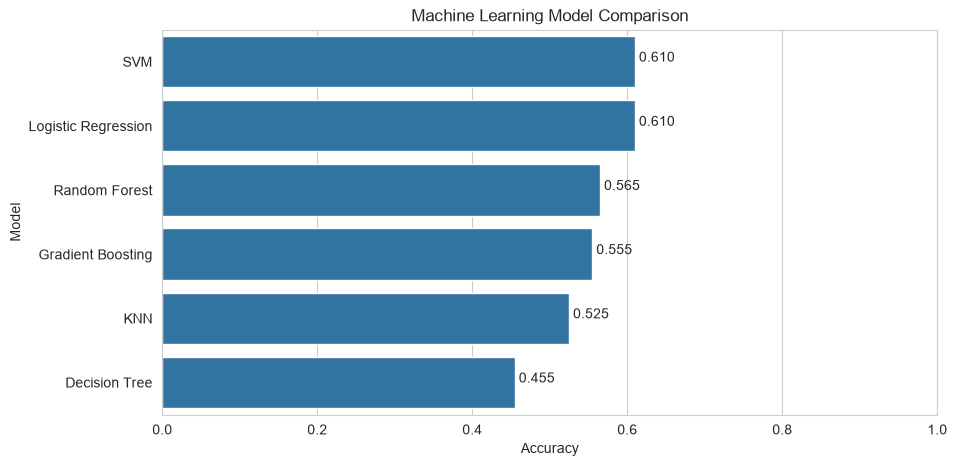

In [39]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Accuracy",
    y="Model"
)

plt.title("Machine Learning Model Comparison")

plt.xlim(0,1)

for index, value in enumerate(comparison["Accuracy"]):
    plt.text(
        value + 0.005,
        index,
        f"{value:.3f}"
    )

plt.show()

In [40]:
comparison.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("✅ Comparison Saved")

✅ Comparison Saved


In [41]:
best_model = comparison.iloc[0]

print("="*50)
print("🏆 BEST MODEL")
print("="*50)

print(f"Model : {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.4f}")

🏆 BEST MODEL
Model : SVM
Accuracy : 0.6100


In [42]:
import joblib

joblib.dump(best_rf.feature_importances_, "../models/feature_importance.pkl")

print("Feature importance saved successfully!")

Feature importance saved successfully!
